In [1]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Dropout,BatchNormalization
from tensorflow.keras.optimizers import SGD,Adam
from tensorflow.keras.callbacks import EarlyStopping

In [2]:
import sys
!{sys.executable} -m pip install scikit-learn

In [3]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

In [4]:
import sys
!{sys.executable} -m pip install matplotlib pandas numpy

In [5]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np


X, y = make_classification(
    n_samples=5000,
    n_features=20,
    n_informative=15,
    n_redundant=5,
    n_classes=2,
    random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(X_train.shape)
print(X_test.shape)


(4000, 20)
(1000, 20)


In [6]:
print("Single neuron")
single_neuron=Sequential([
    Dense(1,activation='sigmoid',input_shape=(20,))
])
single_neuron.compile(
    optimizer='sgd',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
history_single=single_neuron.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    verbose=0
)

Single neuron


/opt/anaconda3/envs/tf/lib/python3.12/site-packages/keras/src/layers/core/dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [11]:
print("Deep learning network")
dnn_model=Sequential([
    Dense(128,activation='relu',input_shape=(20,)),
    BatchNormalization(),

    Dense(64,activation='relu'),
    Dropout(0.3),

    Dense(32,activation='relu'),
    BatchNormalization(),

    Dense(16,activation='relu'),
    Dropout(0.2),

    Dense(1,activation='sigmoid')
])


Deep learning network


In [12]:
sgd_optimizer=SGD(
    learning_rate=0.01,
    momentum=0.9
)

dnn_model.compile(
    optimizer=sgd_optimizer,
    loss='binary_crossentropy',
    metrics=['accuracy']
)


In [14]:
early_stop=EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history_dnn=dnn_model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8181 - loss: 0.4013 - val_accuracy: 0.9438 - val_loss: 0.2565
Epoch 2/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 511us/step - accuracy: 0.9237 - loss: 0.2249 - val_accuracy: 0.9463 - val_loss: 0.1524
Epoch 3/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 512us/step - accuracy: 0.9422 - loss: 0.1790 - val_accuracy: 0.9625 - val_loss: 0.1225
Epoch 4/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 520us/step - accuracy: 0.9459 - loss: 0.1635 - val_accuracy: 0.9663 - val_loss: 0.1010
Epoch 5/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 526us/step - accuracy: 0.9494 - loss: 0.1566 - val_accuracy: 0.9700 - val_loss: 0.0981
Epoch 6/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 519us/step - accuracy: 0.9581 - loss: 0.1274 - val_accuracy: 0.9650 - val_loss: 0.1054
Epoch 7/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 539us/step - accuracy: 0.9638 - loss: 0.1193 - val_accuracy: 0.9712 - val_loss: 0.0971
Epoch 8/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 560us/step - accuracy: 0.9619 - loss: 0.1

In [20]:
print("Model evaluation")
loss,accuracy=dnn_model.evaluate(X_test,y_test)
print(f"\nTest accuarcy: {accuracy:.4f}")

y_pred_prob=dnn_model.predict(X_test)
y_pred=(y_pred_prob>0.5).astype(int)

print("\nClassification report:\n")
print(classification_report(y_test,y_pred))

cm=confusion_matrix(y_test,y_pred)
print("\nConfusion Matrix:\n")
print(cm)



Model evaluation
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 593us/step - accuracy: 0.9780 - loss: 0.0787

Test accuarcy: 0.9780
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 326us/step

Classification report:

              precision    recall  f1-score   support

           0       0.99      0.97      0.98       507
           1       0.97      0.99      0.98       493

    accuracy                           0.98      1000
   macro avg       0.98      0.98      0.98      1000
weighted avg       0.98      0.98      0.98      1000


Confusion Matrix:

[[491  16]
 [  6 487]]


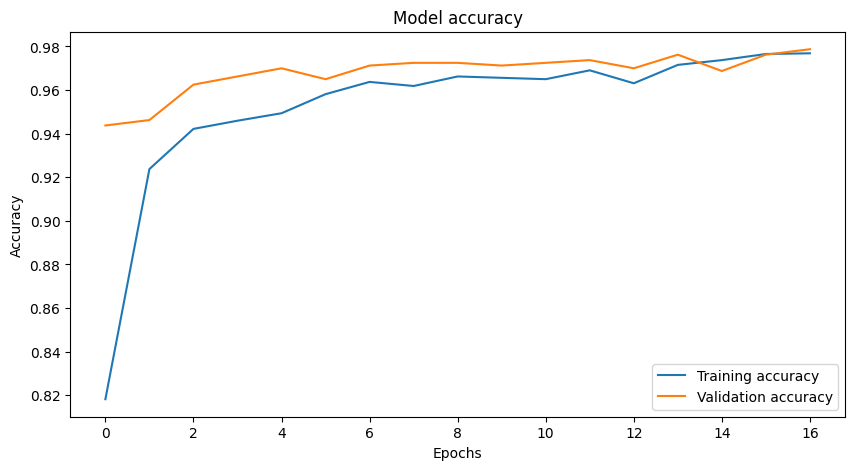

In [21]:
plt.figure(figsize=(10,5))
plt.plot(history_dnn.history['accuracy'],label='Training accuracy')
plt.plot(history_dnn.history['val_accuracy'],label='Validation accuracy')

plt.title('Model accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [24]:
print("Adam optimizer comparsion")
adam_model=Sequential([
    Dense(128,activation='relu',input_shape=(20,)),
    BatchNormalization(),

    Dense(64,activation='relu'),
    Dropout(0.3),

    Dense(1,activation='sigmoid')
])

adam_model.compile(
    optimizer=Adam(learning_rate=0.01),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_adam=adam_model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

adam_loss,adam_accuracy=adam_model.evaluate(X_test,y_test)
print(f"\nAdam accuracy: {adam_accuracy:.4f}")
print(f"SGD accuracy: {accuracy:.4f}")

Adam optimizer comparsion
Epoch 1/30


/opt/anaconda3/envs/tf/lib/python3.12/site-packages/keras/src/layers/core/dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 992us/step - accuracy: 0.9069 - loss: 0.2713 - val_accuracy: 0.9500 - val_loss: 0.1762
Epoch 2/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 459us/step - accuracy: 0.9488 - loss: 0.1653 - val_accuracy: 0.9450 - val_loss: 0.1379
Epoch 3/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 490us/step - accuracy: 0.9525 - loss: 0.1421 - val_accuracy: 0.9700 - val_loss: 0.1118
Epoch 4/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 468us/step - accuracy: 0.9566 - loss: 0.1339 - val_accuracy: 0.9638 - val_loss: 0.1386
Epoch 5/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 474us/step - accuracy: 0.9622 - loss: 0.1131 - val_accuracy: 0.9500 - val_loss: 0.1822
Epoch 6/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 479us/step - accuracy: 0.9659 - loss: 0.1133 - val_accuracy: 0.9712 - val_loss: 0.1239
Epoch 7/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 481us/step - accuracy: 0.9716 - loss: 0.1037 - val_accuracy: 0.9712 - val_loss: 0.1135
Epoch 8/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 501us/step - accuracy: 0.9734 - loss: 0.0910 - val_accurac

In [27]:
dnn_model.save("deep_learning_project_model.h5")
print("\nModel saved successfully!")


Model saved successfully!
